# **Install Kaggle API and upload credentials**

In [2]:
# Install kaggle package (usually pre-installed in Colab, but just in case)
!pip install -q kaggle


In [3]:
!git config --global user.email "it25100310@my.sliit.lk"
!git config --global user.name "D M L M Bandara-IT25100310"

# The branch 'IT25100310-missing-data' already exists, so no need to checkout -b again.

!git status

# Add the generated visualization file.
!git add results/eda_visualizations/pixel_scaling_comparison.png

!git commit -m "Add EDA visualization for pixel scaling"

!git push https://github.com/IT25100310/Indoor-Plant-Disease-Dataset

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


# **Download and unzip the dataset**

In [4]:
!kaggle datasets download -d aditisalvi04/indoor-plant-disease-dataset

!unzip -q indoor-plant-disease-dataset.zip -d plant_dataset

Dataset URL: https://www.kaggle.com/datasets/aditisalvi04/indoor-plant-disease-dataset
License(s): MIT
100% 7.79G/7.79G [01:52<00:00, 74.4MB/s]



# **Check folder structure**

In [5]:
import os

for root, dirs, files_ in os.walk("plant_dataset"):
    print(root, "->", len(files_), "files")
    if len(dirs) > 0:
        print("   subfolders:", dirs)

plant_dataset -> 0 files
   subfolders: ['Final Dataset']
plant_dataset/Final Dataset -> 0 files
   subfolders: ['Turmeric', 'Money Plant', 'Rose', 'Chrysanthemum', 'Hibiscus', 'Aloe Vera']
plant_dataset/Final Dataset/Turmeric -> 0 files
   subfolders: ['Turmeric_Leaf_Necrosis', 'Turmeric_Blotch', 'Turmeric_Healthy', 'Turmeric_Leaf_Spot', 'Turmeric_Aphid_Infestation']
plant_dataset/Final Dataset/Turmeric/Turmeric_Leaf_Necrosis -> 812 files
plant_dataset/Final Dataset/Turmeric/Turmeric_Blotch -> 1904 files
plant_dataset/Final Dataset/Turmeric/Turmeric_Healthy -> 1806 files
plant_dataset/Final Dataset/Turmeric/Turmeric_Leaf_Spot -> 919 files
plant_dataset/Final Dataset/Turmeric/Turmeric_Aphid_Infestation -> 847 files
plant_dataset/Final Dataset/Money Plant -> 0 files
   subfolders: ['Money_Plant_Chlorosis', 'Money_Plant_Healthy', 'Money_Plant_Manganese_Toxicity', 'Money_Plant_Bacterial_Wilt']
plant_dataset/Final Dataset/Money Plant/Money_Plant_Chlorosis -> 115 files
plant_dataset/Final D

# **Set up image parameters**

In [6]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
DATASET_DIR = "plant_dataset"   # adjust if unzip created a nested folder

# **: Load dataset with normalization**

In [7]:
import tensorflow as tf

# Load raw dataset (pixels still 0-255)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 49878 files belonging to 1 classes.
Using 39903 files for training.
Found 49878 files belonging to 1 classes.
Using 9975 files for validation.
Classes: ['Final Dataset']


# **Apply normalization**

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Verify it worked
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
print("Min pixel value:", first_image.numpy().min())
print("Max pixel value:", first_image.numpy().max())

Min pixel value: 0.0
Max pixel value: 0.95294124


# **Standardization instead of 0–1 scaling**

In [9]:
import numpy as np

# Compute mean and std over a sample of the training set
means = []
stds = []

for images, _ in train_ds.take(20):  # sample batches
    means.append(np.mean(images.numpy(), axis=(0,1,2)))
    stds.append(np.std(images.numpy(), axis=(0,1,2)))

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)
print("Mean:", mean, "Std:", std)

def standardize(image, label):
    image = (image - mean) / std
    return image, label

train_ds_standardized = train_ds.map(standardize)
val_ds_standardized = val_ds.map(standardize)

Mean: [0.49186382 0.50619996 0.42555046] Std: [0.35334215 0.34890214 0.37556157]


# **Improve performance**

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# **# Count images per class**

Contents of DATASET_DIR: ['Final Dataset']
Found 49878 files belonging to 1 classes.
Using 39903 files for training.
Found 49878 files belonging to 1 classes.
Using 9975 files for validation.
Classes found: ['Final Dataset']
           class  count
0  Final Dataset      6


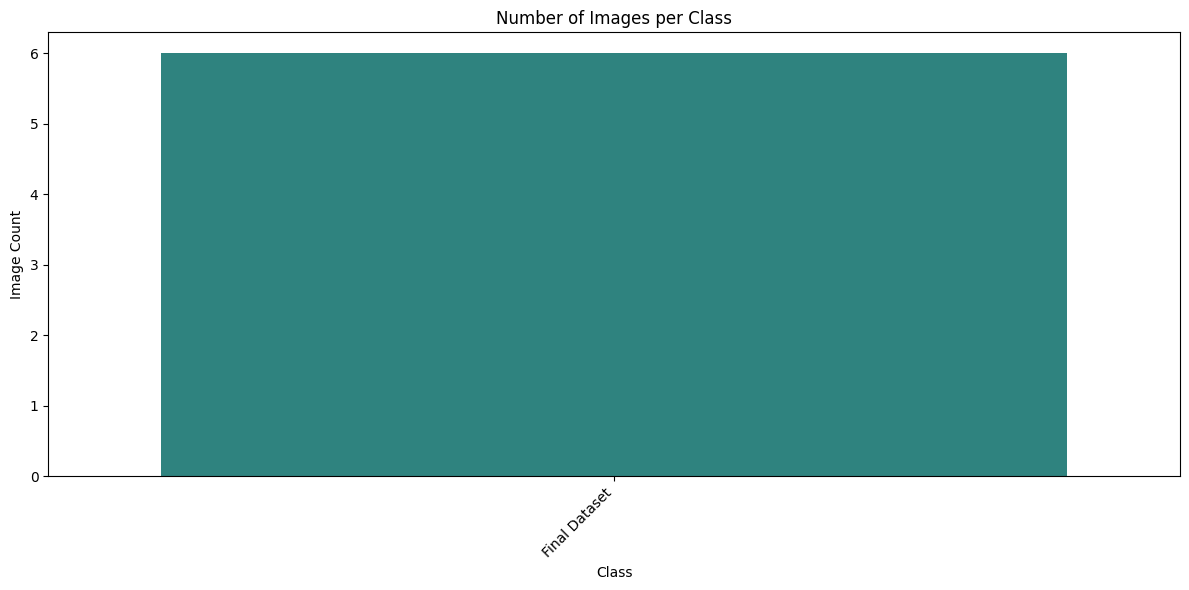

In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Step 5: Parameters ---
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
DATASET_DIR = "plant_dataset"   # <-- check this matches your actual unzip folder

# --- Check dataset exists ---
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"'{DATASET_DIR}' not found. You need to re-download and unzip the dataset first "
        f"(kaggle download + unzip steps)."
    )

print("Contents of DATASET_DIR:", os.listdir(DATASET_DIR))

# --- Step 6: Load dataset ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes found:", class_names)

# --- Step 7: Normalize ---
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# --- Step 9: Performance ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- Step 12: Count images per class ---
data = []
for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_dir):
        count = len(os.listdir(class_dir))
        data.append({"class": class_name, "count": count})

df = pd.DataFrame(data)
print(df)

# --- Step 13: Plot ---
if df.empty:
    print("df is empty — class folders not found directly under DATASET_DIR. "
          "Your dataset may be nested one level deeper.")
else:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="class", y="count", hue="class", palette="viridis", legend=False)
    plt.xticks(rotation=45, ha="right")
    plt.title("Number of Images per Class")
    plt.xlabel("Class")
    plt.ylabel("Image Count")
    plt.tight_layout()
    plt.show()

In [11]:
import os

sample_class_dir = "plant_dataset/Final Dataset/Turmeric"

for root, dirs, files in os.walk(sample_class_dir):
    print(root, "-> dirs:", dirs, "| files:", len(files))

plant_dataset/Final Dataset/Turmeric -> dirs: ['Turmeric_Leaf_Necrosis', 'Turmeric_Blotch', 'Turmeric_Healthy', 'Turmeric_Leaf_Spot', 'Turmeric_Aphid_Infestation'] | files: 0
plant_dataset/Final Dataset/Turmeric/Turmeric_Leaf_Necrosis -> dirs: [] | files: 812
plant_dataset/Final Dataset/Turmeric/Turmeric_Blotch -> dirs: [] | files: 1904
plant_dataset/Final Dataset/Turmeric/Turmeric_Healthy -> dirs: [] | files: 1806
plant_dataset/Final Dataset/Turmeric/Turmeric_Leaf_Spot -> dirs: [] | files: 919
plant_dataset/Final Dataset/Turmeric/Turmeric_Aphid_Infestation -> dirs: [] | files: 847


Using sample image: plant_dataset/Final Dataset/Turmeric/Turmeric_Leaf_Necrosis/Dry Leaf00058_aug_231.jpg


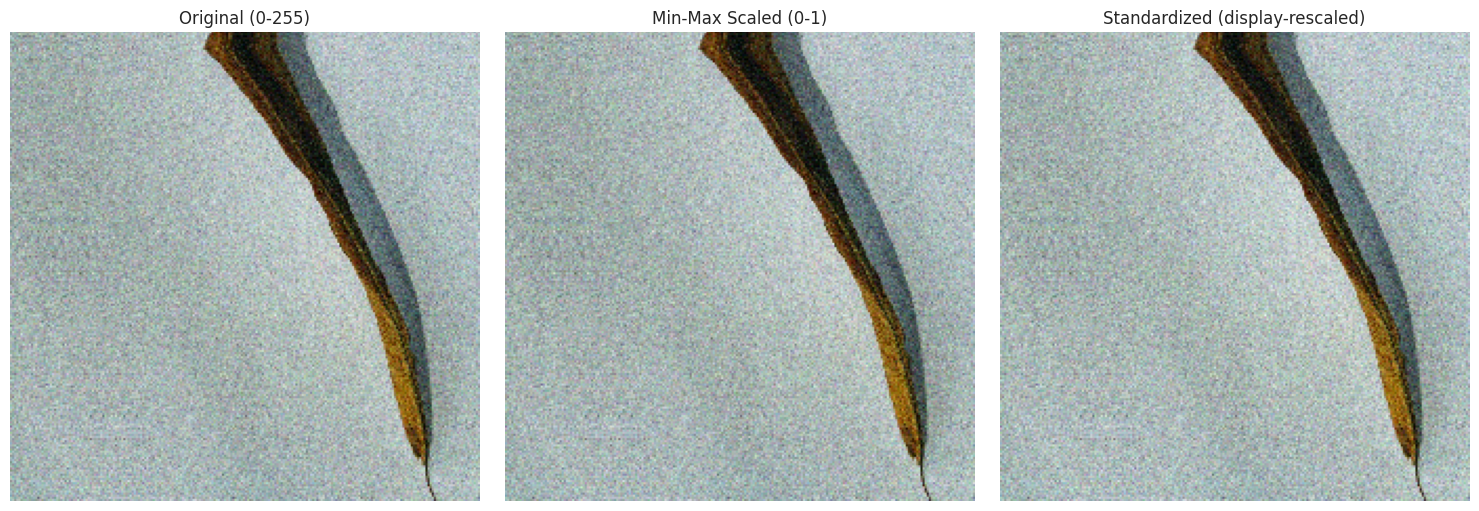

Original pixel range: 0 - 249
Scaled pixel range: 0.0 - 0.9764706
Standardized pixel range: -3.9512098 - 2.0220761


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Pick a sample image from one of the leaf class folders ---
sample_class_dir = class_dirs[0]  # e.g. Aloe_Anthracnose
sample_files = [f for f in os.listdir(sample_class_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_path = os.path.join(sample_class_dir, sample_files[0])
print("Using sample image:", sample_path)

# --- Load original image (0-255) ---
img = tf.keras.utils.load_img(sample_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_resized = tf.keras.utils.img_to_array(img).astype("uint8")

# --- Min-Max scaled version (0-1) ---
img_scaled = img_resized.astype("float32") / 255.0

# --- Standardized version (zero mean, unit variance) ---
mean = img_scaled.mean()
std = img_scaled.std()
img_standardized = (img_scaled - mean) / std

# ---- 1. Images side-by-side: Original vs Scaled vs Standardized ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_resized)
axes[0].set_title("Original (0-255)")
axes[0].axis('off')

axes[1].imshow(img_scaled)
axes[1].set_title("Min-Max Scaled (0-1)")
axes[1].axis('off')

# standardized images have negative values, so rescale just for display
img_std_display = (img_standardized - img_standardized.min()) / (img_standardized.max() - img_standardized.min())
axes[2].imshow(img_std_display)
axes[2].set_title("Standardized (display-rescaled)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Original pixel range:", img_resized.min(), "-", img_resized.max())
print("Scaled pixel range:", img_scaled.min(), "-", img_scaled.max())
print("Standardized pixel range:", img_standardized.min(), "-", img_standardized.max())

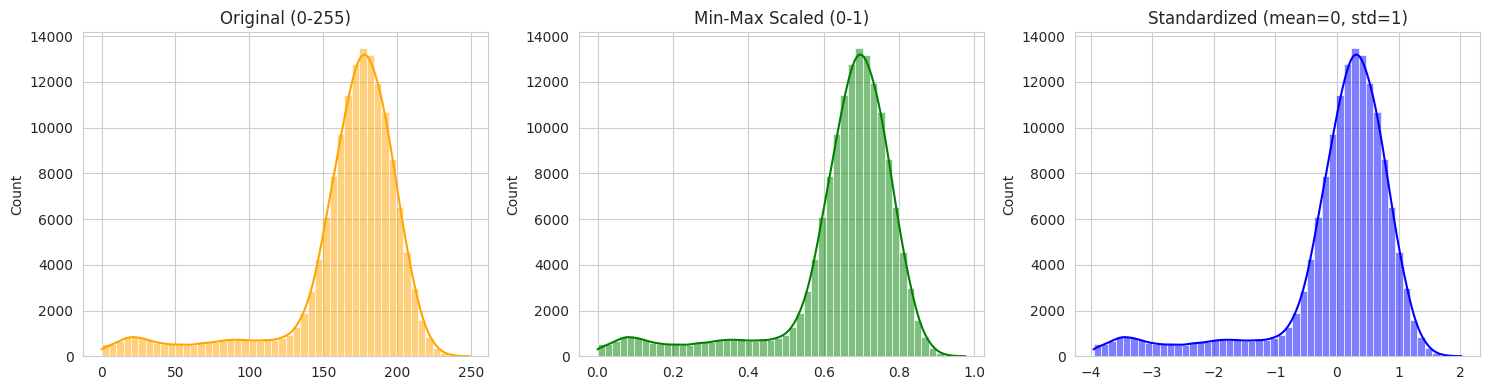

Standardized mean: 9.812465e-08 | std: 1.0


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 2. Pixel distribution comparison using seaborn ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(img_resized.ravel(), bins=50, color='orange', ax=axes[0], kde=True)
axes[0].set_title("Original (0-255)")

sns.histplot(img_scaled.ravel(), bins=50, color='green', ax=axes[1], kde=True)
axes[1].set_title("Min-Max Scaled (0-1)")

sns.histplot(img_standardized.ravel(), bins=50, color='blue', ax=axes[2], kde=True)
axes[2].set_title("Standardized (mean=0, std=1)")

plt.tight_layout()
plt.show()

print("Standardized mean:", img_standardized.mean(), "| std:", img_standardized.std())